# Datenaufbereitung für Prophet — PM2.5 Beijing

**Capstone-Projekt · CRISP-DM Phase 3 (Data Preparation)**  
Bettina Gertjerenken · Kai Steffen

Dieses Notebook bereitet die Rohdaten **speziell für Facebook Prophet** auf:

1. eine Station laden (später leicht auf alle 12 erweiterbar),
2. auf ein lückenloses Stundenraster bringen,
3. fehlende Werte auffüllen (Imputation),
4. **Windrichtung `wd` kodieren** (zyklisch als sin/cos),
5. in das von Prophet erwartete Format `ds` / `y` bringen,
6. **chronologischen Train/Test-Split nach 3 Jahren** erzeugen,
7. mit Sanity-Checks absichern und speichern.

> **Prophet-Format:** Prophet braucht immer genau zwei Pflichtspalten: `ds` (Zeitstempel) und `y` (Zielwert = PM2.5). 
Zusätzliche **numerische** Spalten dürfen als Regressoren dienen.

## 1. Bibliotheken & eine Station laden

Prophet ist **univariat** (eine Zeitreihe pro Modell). Wir starten mit einer repräsentativen Station. 
Über `STATION` wählt ihr jede andere oder loopt später über alle 12.

In [1]:
import glob, os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data/PRSA_Data_20130301-20170228")
if not DATA_DIR.exists():
    DATA_DIR = Path("capstone projekt/data/PRSA_Data_20130301-20170228")

STATION = "Aotizhongxin"                       # <-- spaeter andere Station / Schleife
NUM_REGS = ["TEMP", "DEWP", "PRES", "WSPM", "RAIN"]   # numerische Wetter-Regressoren

df = pd.read_csv(DATA_DIR / f"PRSA_Data_{STATION}_20130301-20170228.csv")
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

# PM2.5 + numerische Regressoren + Windrichtung (kategorial) laden
s = (df[["datetime", "PM2.5"] + NUM_REGS + ["wd"]]
       .sort_values("datetime")
       .set_index("datetime"))

print(f"Station: {STATION}")
print(f"Zeilen: {len(df)}")
print(f"Zeitraum: {s.index.min()} bis {s.index.max()}")

Station: Aotizhongxin
Zeilen: 35064
Zeitraum: 2013-03-01 00:00:00 bis 2017-02-28 23:00:00


## 2. Lückenloses Stundenraster herstellen

Ein **regelmäßiges Zeitraster** macht Split und Imputation sauberer. Wir legen einen durchgehenden 
Stundenindex an (`reindex`); fehlende Stunden werden dadurch explizit zu `NaN`.

In [2]:
voll = pd.date_range(s.index.min(), s.index.max(), freq="h")
s = s.reindex(voll)
print(f"Stunden im Raster: {len(s)}")

Stunden im Raster: 35064


## 3. Fehlende Werte auffüllen (Imputation)

Zuerst zählen, **wie viel fehlt**:

In [3]:
s.isna().sum()

PM2.5    925
TEMP      20
DEWP      20
PRES      20
WSPM      14
RAIN      20
wd        81
dtype: int64

Die **numerischen** Spalten füllen wir mit **zeitlicher Interpolation** (`method="time"`): fehlende Werte 
werden linear zwischen den benachbarten echten Messwerten geschätzt, gewichtet nach zeitlichem Abstand. 
`limit_direction="both"` füllt auch Ränder.

> ⚠️ Die kategoriale Spalte `wd` kann man **nicht** interpolieren — die behandeln wir gleich separat (Abschnitt 4).

> ⚠️ Bei sehr langen Lücken ist lineare Interpolation nur eine Näherung. Für die finale Modellierung ggf. `limit=...` setzen.

In [4]:
s_imp = s.copy()
s_imp[["PM2.5"] + NUM_REGS] = s[["PM2.5"] + NUM_REGS].interpolate(
    method="time", limit_direction="both")
print("Fehlende Werte NACH Imputation (numerisch):")
print(s_imp[["PM2.5"] + NUM_REGS].isna().sum())

Fehlende Werte NACH Imputation (numerisch):
PM2.5    0
TEMP     0
DEWP     0
PRES     0
WSPM     0
RAIN     0
dtype: int64


Wo Lücken lagen (rote Balken = PM2.5 fehlte):

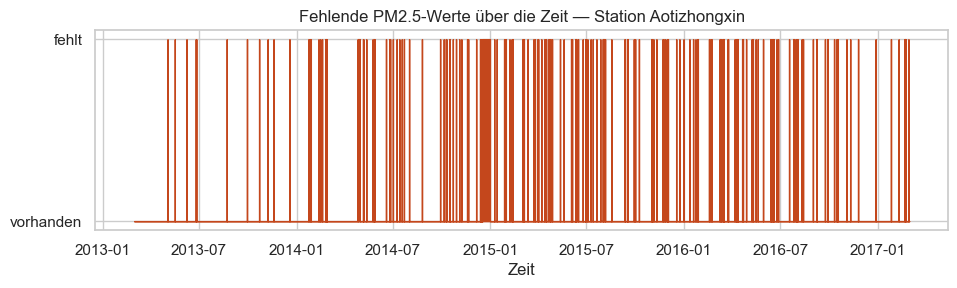

In [5]:
plt.figure(figsize=(11, 2.6))
luecke = s["PM2.5"].isna().astype(int)
plt.fill_between(s.index, luecke, step="mid", color="#C4471C")
plt.yticks([0, 1], ["vorhanden", "fehlt"])
plt.title(f"Fehlende PM2.5-Werte über die Zeit — Station {STATION}")
plt.xlabel("Zeit"); plt.show()

Eine aufgefüllte Lücke konkret (orange = interpoliert):

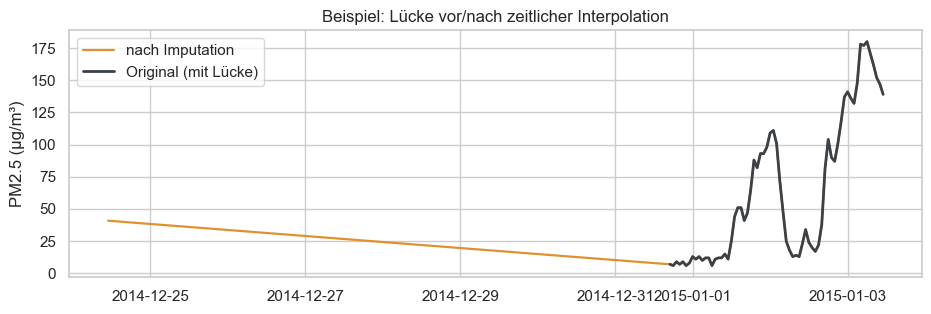

In [6]:
na_idx = s.index[s["PM2.5"].isna()]
mitte = na_idx[len(na_idx)//2]
w = pd.Timedelta(days=5)
seg  = s.loc[mitte-w:mitte+w, "PM2.5"]
segi = s_imp.loc[mitte-w:mitte+w, "PM2.5"]
plt.figure(figsize=(11, 3.2))
plt.plot(segi.index, segi.values, color="#E0912F", lw=1.6, label="nach Imputation")
plt.plot(seg.index, seg.values, color="#3A4148", lw=2.0, label="Original (mit Lücke)")
plt.title("Beispiel: Lücke vor/nach zeitlicher Interpolation")
plt.ylabel("PM2.5 (µg/m³)"); plt.legend(); plt.show()

## 4. Windrichtung `wd` kodieren (zyklisch)

Prophet-Regressoren müssen **numerisch** sein — `wd` ist aber Text (`N`, `NNE`, …). 
Eine Windrichtung ist zudem **zyklisch**: `NNW` (337.5°) und `N` (0°) liegen dicht beieinander, obwohl die Zahlen weit auseinander sind. 
Deshalb kodieren wir sie in **zwei** Spalten mit Sinus und Kosinus des Winkels — so bleibt die Nachbarschaft erhalten.

Fehlende `wd`-Werte füllen wir vorher per `ffill`/`bfill` (nächster gültiger Nachbar).

> Alternative: 16 Dummy-Spalten per One-Hot (`pd.get_dummies`). Die sin/cos-Variante ist kompakter (nur 2 Spalten) und spiegelt die Kreisform wider.

In [7]:
# 1) Lücken der Kategorie fuellen
s_imp["wd"] = s_imp["wd"].ffill().bfill()

# 2) 16 Kompassrichtungen -> Grad
kompass = {"N":0, "NNE":22.5, "NE":45, "ENE":67.5, "E":90, "ESE":112.5,
           "SE":135, "SSE":157.5, "S":180, "SSW":202.5, "SW":225, "WSW":247.5,
           "W":270, "WNW":292.5, "NW":315, "NNW":337.5}
grad = s_imp["wd"].map(kompass)

# 3) zyklische sin/cos-Kodierung
s_imp["wd_sin"] = np.sin(np.deg2rad(grad))
s_imp["wd_cos"] = np.cos(np.deg2rad(grad))

# vollstaendige Regressor-Liste fuer Prophet (add_regressor)
REGRESSOREN = NUM_REGS + ["wd_sin", "wd_cos"]
print(REGRESSOREN)
print()
print(s_imp[["wd", "wd_sin", "wd_cos"]].head())

['TEMP', 'DEWP', 'PRES', 'WSPM', 'RAIN', 'wd_sin', 'wd_cos']

                      wd    wd_sin    wd_cos
2013-03-01 00:00:00  NNW -0.382683  0.923880
2013-03-01 01:00:00    N  0.000000  1.000000
2013-03-01 02:00:00  NNW -0.382683  0.923880
2013-03-01 03:00:00   NW -0.707107  0.707107
2013-03-01 04:00:00    N  0.000000  1.000000


Zur Veranschaulichung: die 16 Richtungen liegen als `(wd_sin, wd_cos)` schön auf dem Einheitskreis — 
benachbarte Himmelsrichtungen sind auch im Zahlenraum benachbart.

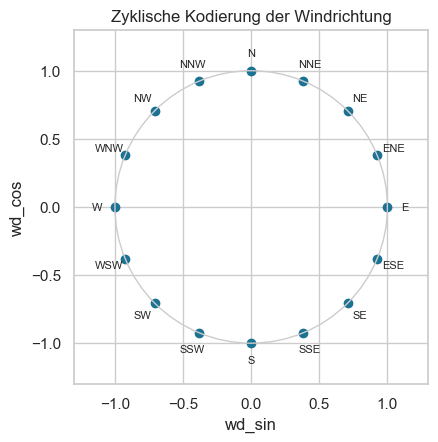

In [8]:
plt.figure(figsize=(4.6, 4.6))
for k, d in kompass.items():
    x, y = np.sin(np.deg2rad(d)), np.cos(np.deg2rad(d))
    plt.scatter(x, y, color="#1C7293")
    plt.text(x*1.13, y*1.13, k, ha="center", va="center", fontsize=8)
plt.gca().add_artist(plt.Circle((0, 0), 1, fill=False, color="#CCC"))
plt.xlim(-1.3, 1.3); plt.ylim(-1.3, 1.3); plt.gca().set_aspect("equal")
plt.xlabel("wd_sin"); plt.ylabel("wd_cos")
plt.title("Zyklische Kodierung der Windrichtung"); plt.show()

## 5. In das Prophet-Format `ds` / `y` bringen

`PM2.5` → `y`, der Zeitindex wird zur Spalte `ds`. Die Regressor-Spalten bleiben erhalten — 
für **univariates** Prophet nutzt ihr nur `ds`+`y`, für **Regressoren** zusätzlich die übrigen Spalten.

In [9]:
prophet_df = (s_imp[["PM2.5"] + REGRESSOREN]
                .rename(columns={"PM2.5": "y"})
                .reset_index())
prophet_df = prophet_df.rename(columns={prophet_df.columns[0]: "ds"})
prophet_df.head()

,ds,y,TEMP,DEWP,PRES,WSPM,RAIN,wd_sin,wd_cos
0,2013-03-01 00:00:00,4.0,-0.7,-18.8,1023.0,4.4,0.0,-0.382683,0.923880
1,2013-03-01 01:00:00,8.0,-1.1,-18.2,1023.2,4.7,0.0,0.000000,1.000000
2,2013-03-01 02:00:00,7.0,-1.1,-18.2,1023.5,5.6,0.0,-0.382683,0.923880
3,2013-03-01 03:00:00,6.0,-1.4,-19.4,1024.5,3.1,0.0,-0.707107,0.707107
4,2013-03-01 04:00:00,3.0,-2.0,-19.5,1025.2,2.0,0.0,0.000000,1.000000


## 6. Train/Test-Split nach 3 Jahren

Die Daten laufen vom **01.03.2013** bis **28.02.2017** — genau **4 Jahre**. 
Wir trainieren auf den ersten **3 Jahren**, testen auf dem letzten Jahr. Split-Grenze: **01.03.2016**.

> 🔑 **Kein Data Leakage:** Zeitreihen werden **chronologisch** getrennt, nie zufällig. Alles vor dem Stichtag ist Training, alles danach Test.

In [10]:
split = pd.Timestamp("2016-03-01")     # nach 3 Jahren

train = prophet_df[prophet_df["ds"] <  split].copy()
test  = prophet_df[prophet_df["ds"] >= split].copy()

print(f"Split-Datum: {split.date()}  (nach 3 Jahren)")
print(f"Training: {train['ds'].min()}  bis  {train['ds'].max()}  ->  {len(train)} Zeilen")
print(f"Test:     {test['ds'].min()}  bis  {test['ds'].max()}  ->  {len(test)} Zeilen")
print(f"Anteil Training: {len(train)/len(prophet_df)*100:.1f}%  |  Test: {len(test)/len(prophet_df)*100:.1f}%")

Split-Datum: 2016-03-01  (nach 3 Jahren)
Training: 2013-03-01 00:00:00  bis  2016-02-29 23:00:00  ->  26304 Zeilen
Test:     2016-03-01 00:00:00  bis  2017-02-28 23:00:00  ->  8760 Zeilen
Anteil Training: 75.0%  |  Test: 25.0%


Training (blau, 3 Jahre) vs. Test (rot, 1 Jahr):

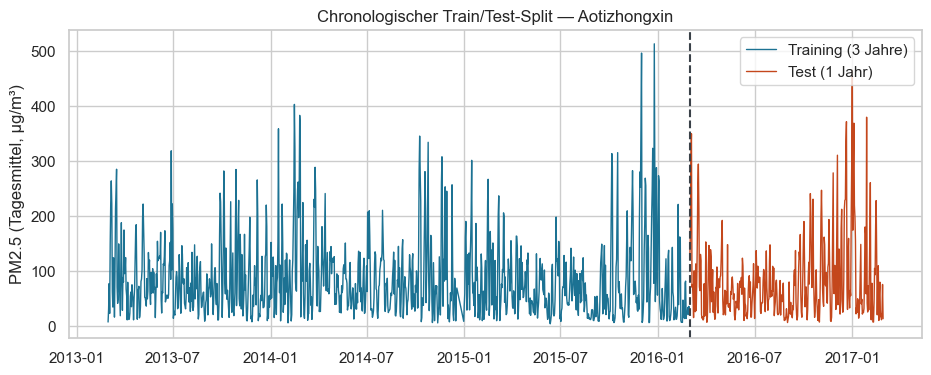

In [11]:
plt.figure(figsize=(11, 4))
tr = train.set_index("ds")["y"].resample("D").mean()   # Tagesmittel nur zur Anzeige
te = test.set_index("ds")["y"].resample("D").mean()
plt.plot(tr.index, tr.values, color="#1C7293", lw=1.0, label="Training (3 Jahre)")
plt.plot(te.index, te.values, color="#C4471C", lw=1.0, label="Test (1 Jahr)")
plt.axvline(split, color="#3A4148", ls="--", lw=1.5)
plt.ylabel("PM2.5 (Tagesmittel, µg/m³)")
plt.title(f"Chronologischer Train/Test-Split — {STATION}")
plt.legend(loc="upper right"); plt.show()

Plausibilitätscheck — Verteilung Training vs. Test:

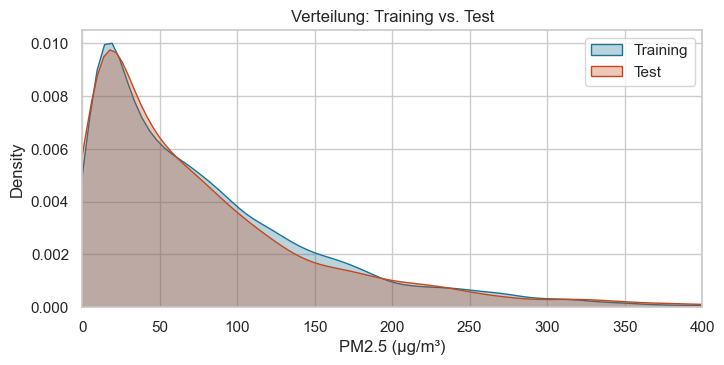

In [12]:
plt.figure(figsize=(8, 3.6))
sns.kdeplot(train["y"], color="#1C7293", fill=True, alpha=.3, label="Training")
sns.kdeplot(test["y"],  color="#C4471C", fill=True, alpha=.3, label="Test")
plt.xlim(0, 400); plt.xlabel("PM2.5 (µg/m³)")
plt.title("Verteilung: Training vs. Test"); plt.legend(); plt.show()

## 7. Sanity-Checks

Vor dem Speichern prüfen wir, dass alles sauber ist — inkl. **keine NaN in den Regressoren**:

In [13]:
print("Sanity-Checks:")
print(f"  y hat NaN?  train={train['y'].isna().any()}  test={test['y'].isna().any()}")
print(f"  Regressoren NaN?  {prophet_df[REGRESSOREN].isna().any().any()}")
print(f"  ds sortiert & eindeutig? {prophet_df['ds'].is_monotonic_increasing and prophet_df['ds'].is_unique}")
print(f"  Kein Overlap (max train < min test)? {train['ds'].max() < test['ds'].min()}")
print(f"  Spalten: {list(prophet_df.columns)}")

Sanity-Checks:
  y hat NaN?  train=False  test=False
  Regressoren NaN?  False
  ds sortiert & eindeutig? True
  Kein Overlap (max train < min test)? True
  Spalten: ['ds', 'y', 'TEMP', 'DEWP', 'PRES', 'WSPM', 'RAIN', 'wd_sin', 'wd_cos']


## 8. Speichern für die Modellierung (Phase 4)

In [14]:
out = Path("../data/prepared/basis")
out.mkdir(parents=True, exist_ok=True)
train.to_csv(out / f"prophet_train_{STATION}.csv", index=False)
test.to_csv(out / f"prophet_test_{STATION}.csv", index=False)
print("gespeichert:")
print("  ", out / f"prophet_train_{STATION}.csv", f"({len(train)} Zeilen)")
print("  ", out / f"prophet_test_{STATION}.csv",  f"({len(test)} Zeilen)")

gespeichert:
   ..\data\prepared\basis\prophet_train_Aotizhongxin.csv (26304 Zeilen)
   ..\data\prepared\basis\prophet_test_Aotizhongxin.csv (8760 Zeilen)


## 9. Alle 12 Stationen in einer Schleife

Bisher haben wir **eine** Station aufbereitet. Jetzt packen wir die exakt gleichen Schritte (Raster → Imputation → Windrichtung kodieren → `ds`/`y` → Split) in eine **Funktion** und lassen sie über **alle 12 Stationen** laufen. Je Station entsteht ein eigenes `prophet_train_<Station>.csv` / `prophet_test_<Station>.csv`.

> So sind am Ende **alle Zeitreihen modellfertig** — nicht nur die Beispielstation.

In [15]:
def station_aufbereiten(station):
    """Rohdaten einer Station -> (train, test, pm25_luecken_prozent). Gleiche Schritte wie oben."""
    d = pd.read_csv(DATA_DIR / f"PRSA_Data_{station}_20130301-20170228.csv")
    d["datetime"] = pd.to_datetime(d[["year", "month", "day", "hour"]])
    ss = (d[["datetime", "PM2.5"] + NUM_REGS + ["wd"]]
            .sort_values("datetime").set_index("datetime"))
    ss = ss.reindex(pd.date_range(ss.index.min(), ss.index.max(), freq="h"))

    pm25_luecken = ss["PM2.5"].isna().mean() * 100          # vor Imputation (zur Kontrolle)

    # Imputation (numerisch) + Windrichtung fuellen & zyklisch kodieren
    ss[["PM2.5"] + NUM_REGS] = ss[["PM2.5"] + NUM_REGS].interpolate(method="time", limit_direction="both")
    ss["wd"] = ss["wd"].ffill().bfill()
    grad = ss["wd"].map(kompass)
    ss["wd_sin"] = np.sin(np.deg2rad(grad))
    ss["wd_cos"] = np.cos(np.deg2rad(grad))

    # Prophet-Format + Split nach 3 Jahren
    pdf = ss[["PM2.5"] + REGRESSOREN].rename(columns={"PM2.5": "y"}).reset_index()
    pdf = pdf.rename(columns={pdf.columns[0]: "ds"})
    tr = pdf[pdf["ds"] <  split].copy()
    te = pdf[pdf["ds"] >= split].copy()
    return tr, te, pm25_luecken

# alle Stationsnamen automatisch aus den Dateinamen holen
stationen = [pp.name.replace("PRSA_Data_", "").replace("_20130301-20170228.csv", "")
             for pp in sorted(DATA_DIR.glob("*.csv"))]

out = Path("../data/prepared/basis"); out.mkdir(parents=True, exist_ok=True)
zusammenfassung = []
for st in stationen:
    tr, te, gap = station_aufbereiten(st)
    tr.to_csv(out / f"prophet_train_{st}.csv", index=False)
    te.to_csv(out / f"prophet_test_{st}.csv",  index=False)
    zusammenfassung.append({"Station": st, "PM2.5-Lücken %": round(gap, 1),
                            "Train": len(tr), "Test": len(te),
                            "y NaN": bool(tr['y'].isna().any() or te['y'].isna().any())})

summary = pd.DataFrame(zusammenfassung)
print(summary.to_string(index=False))
print(f"\nAlle {len(stationen)} Stationen aufbereitet & gespeichert. "
      f"Train gesamt: {summary['Train'].sum()}, Test gesamt: {summary['Test'].sum()}")

      Station  PM2.5-Lücken %  Train  Test  y NaN
 Aotizhongxin             2.6  26304  8760  False
    Changping             2.2  26304  8760  False
     Dingling             2.2  26304  8760  False
       Dongsi             2.1  26304  8760  False
     Guanyuan             1.8  26304  8760  False
      Gucheng             1.8  26304  8760  False
      Huairou             2.7  26304  8760  False
 Nongzhanguan             1.8  26304  8760  False
       Shunyi             2.6  26304  8760  False
      Tiantan             1.9  26304  8760  False
       Wanliu             1.1  26304  8760  False
Wanshouxigong             2.0  26304  8760  False

Alle 12 Stationen aufbereitet & gespeichert. Train gesamt: 315648, Test gesamt: 105120


## 10. Optionale Behandlung: lange Lücken, Ausreißer & Schiefe (Vergleich)

Die bisherige Aufbereitung (Abschnitte 1–9) ist die **Basis-Variante**. Aus dem Datenverständnis (Kapitel 02) blieben drei Punkte offen. 
Hier erzeugen wir zusätzlich eine **behandelte Variante** und speichern **beide getrennt**, damit ihr sie später vergleichen könnt:

1. **Lange Lücken:** Interpolation nur bis `MAX_GAP_H = 24 h` (`limit=`). Längere Blöcke bleiben `NaN` und werden entfernt, statt sie mit einer geraden Linie zu erfinden.
2. **Ausreißer:** Kappen (`clip`) auf das **99,9-Perzentil des Trainings** (kein Leakage) — extreme Werte Richtung 999 werden gedeckelt. **Gekappt werden nur die _Trainings_-Zielwerte**; die Test-Zielwerte bleiben echt, damit die spätere Fehlermessung fair gegen die tatsächlichen Smog-Spitzen läuft (RMSE reagiert stark auf genau diese Extremwerte).
3. **Rechtsschiefe:** zusätzliche Spalte **`y_log = log1p(y)`** — deutlich symmetrischer, oft besser für die Modellierung.

> **Wir behandeln nur die Zielgröße PM2.5** so; die Wetter-Regressoren lassen wir wie in der Basis.

**Verzeichnisse:**  `../data/prepared/basis/`  (unbehandelt)  vs.  `../data/prepared/behandelt/`  (behandelt).

In [16]:
MAX_GAP_H = 24            # max. Lückenlänge, die interpoliert wird (Stunden)
OUT_CAP_PCT = 99.9        # Perzentil (aus TRAIN) fürs Ausreißer-Kappen

def station_behandelt(station):
    """Behandelte Variante: Lücken-Limit + Ausreißer-Cap + Log-Spalte."""
    d = pd.read_csv(DATA_DIR / f"PRSA_Data_{station}_20130301-20170228.csv")
    d["datetime"] = pd.to_datetime(d[["year", "month", "day", "hour"]])
    ss = (d[["datetime", "PM2.5"] + NUM_REGS + ["wd"]]
            .sort_values("datetime").set_index("datetime"))
    ss = ss.reindex(pd.date_range(ss.index.min(), ss.index.max(), freq="h"))

    # (2) Ausreisser-Cap aus TRAIN bestimmen und NUR auf die TRAININGS-Zielwerte anwenden.
    #     Die Test-Zielwerte bleiben ECHT/ungekappt -> faire Bewertung (kein Leakage, kein leichteres Ziel).
    cap = np.nanpercentile(ss.loc[ss.index < split, "PM2.5"], OUT_CAP_PCT)
    train_mask = ss.index < split
    n_out = int((ss.loc[train_mask, "PM2.5"] > cap).sum())
    ss.loc[train_mask, "PM2.5"] = ss.loc[train_mask, "PM2.5"].clip(upper=cap)

    # (1) Interpolation: Wetter voll, PM2.5 nur bis MAX_GAP_H -> lange Bloecke bleiben NaN
    ss[NUM_REGS] = ss[NUM_REGS].interpolate(method="time", limit_direction="both")
    ss["PM2.5"]  = ss["PM2.5"].interpolate(method="time", limit=MAX_GAP_H)
    n_longgap = int(ss["PM2.5"].isna().sum())

    # Windrichtung kodieren + (3) Log-Spalte
    ss["wd"] = ss["wd"].ffill().bfill()
    grad = ss["wd"].map(kompass)
    ss["wd_sin"] = np.sin(np.deg2rad(grad)); ss["wd_cos"] = np.cos(np.deg2rad(grad))
    ss["y_log"] = np.log1p(ss["PM2.5"])

    pdf = ss[["PM2.5"] + REGRESSOREN + ["y_log"]].rename(columns={"PM2.5": "y"}).reset_index()
    pdf = pdf.rename(columns={pdf.columns[0]: "ds"})
    pdf = pdf.dropna(subset=["y"]).reset_index(drop=True)   # lange Luecken entfernen
    return pdf, cap, n_out, n_longgap

# Schiefe-Kennzahl ohne scipy
def schiefe(x):
    x = np.asarray(x, float); x = x[~np.isnan(x)]; m, s = x.mean(), x.std()
    return float((((x - m) / s) ** 3).mean()) if s > 0 else 0.0

# Vergleich fuer die Beispielstation
basis_df = station_aufbereiten(STATION)[0].pipe(lambda t: pd.concat([t, station_aufbereiten(STATION)[1]]))
beh_df, cap, n_out, n_longgap = station_behandelt(STATION)
print(f"VERGLEICH Station {STATION}:")
print(f"  Cap (p{OUT_CAP_PCT} aus Train):        {cap:.0f} µg/m³")
print(f"  Ausreißer > Cap gekappt:      {n_out}")
print(f"  lange Lücken (> {MAX_GAP_H}h) offen:   {n_longgap}  (in Basis linear gefüllt)")
print(f"  Schiefe y (Basis, gefüllt):   {schiefe(basis_df['y']):.2f}")
print(f"  Schiefe y (behandelt, cap):   {schiefe(beh_df['y']):.2f}")
print(f"  Schiefe y_log (behandelt):    {schiefe(beh_df['y_log']):.2f}")
print(f"  Zeilen Basis (voll):          {len(basis_df)}")
print(f"  Zeilen behandelt (Lücken raus): {len(beh_df)}")

VERGLEICH Station Aotizhongxin:
  Cap (p99.9 aus Train):        573 µg/m³
  Ausreißer > Cap gekappt:      26
  lange Lücken (> 24h) offen:   364  (in Basis linear gefüllt)
  Schiefe y (Basis, gefüllt):   1.98
  Schiefe y (behandelt, cap):   1.92
  Schiefe y_log (behandelt):    -0.30
  Zeilen Basis (voll):          35064
  Zeilen behandelt (Lücken raus): 34700


**Rechtsschiefe:** Links `y` (gekappt) — immer noch stark rechtsschief. Rechts `y_log` — nahezu symmetrisch (Schiefe von ~1,9 auf ~−0,3).

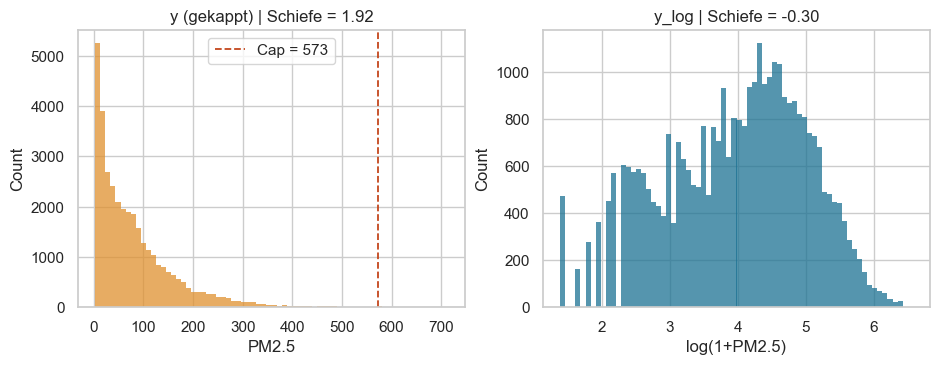

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
sns.histplot(beh_df["y"], bins=70, color="#E0912F", ax=ax[0], edgecolor="none")
ax[0].axvline(cap, color="#C4471C", ls="--", lw=1.3, label=f"Cap = {cap:.0f}")
ax[0].set_title(f"y (gekappt) | Schiefe = {schiefe(beh_df['y']):.2f}"); ax[0].legend(); ax[0].set_xlabel("PM2.5")
sns.histplot(beh_df["y_log"], bins=70, color="#1C7293", ax=ax[1], edgecolor="none")
ax[1].set_title(f"y_log | Schiefe = {schiefe(beh_df['y_log']):.2f}"); ax[1].set_xlabel("log(1+PM2.5)")
plt.show()

**Lange Lücken:** So unterschiedlich gehen beide Varianten mit einem mehrwöchigen Ausfall um — 
die Basis (rot) legt eine gerade Linie durch die Lücke, die behandelte Variante (blau) lässt sie offen.

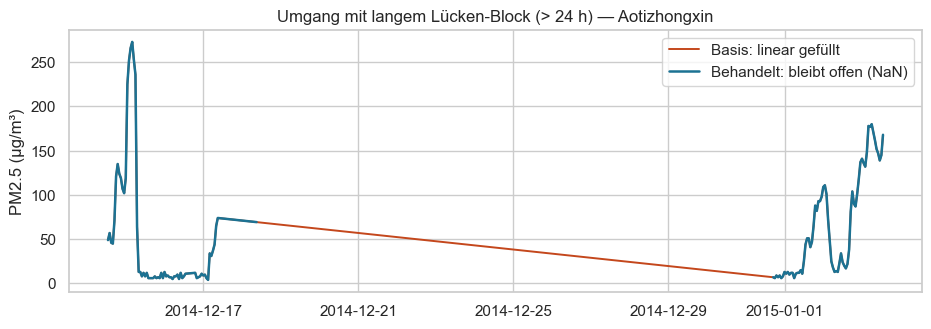

In [18]:
grid = (pd.read_csv(DATA_DIR / f"PRSA_Data_{STATION}_20130301-20170228.csv")
          .assign(ds=lambda d: pd.to_datetime(d[['year','month','day','hour']]))
          .set_index('ds')['PM2.5'])
grid = grid.reindex(pd.date_range(grid.index.min(), grid.index.max(), freq='h'))
# laengsten Luecken-Block finden
na = grid.index[grid.isna()]
blocks, s0, prev = [], None, None
for ts in na:
    if s0 is None: s0 = ts
    elif ts - prev > pd.Timedelta('1h'): blocks.append((s0, prev)); s0 = ts
    prev = ts
blocks.append((s0, prev)); blocks.sort(key=lambda x: x[1]-x[0])
c = blocks[-1][0] + (blocks[-1][1]-blocks[-1][0])/2; w = pd.Timedelta(days=10)
bb = basis_df.set_index('ds')['y'].loc[c-w:c+w]
tt = beh_df.set_index('ds')['y'].reindex(pd.date_range(c-w, c+w, freq='h'))
plt.figure(figsize=(11, 3.4))
plt.plot(bb.index, bb.values, color='#C4471C', lw=1.4, label='Basis: linear gefüllt')
plt.plot(tt.index, tt.values, color='#1C7293', lw=1.8, label='Behandelt: bleibt offen (NaN)')
plt.title(f'Umgang mit langem Lücken-Block (> {MAX_GAP_H} h) — {STATION}')
plt.ylabel('PM2.5 (µg/m³)'); plt.legend(); plt.show()

**Alle 12 Stationen behandelt speichern** (nach `../data/prepared/behandelt/`):

In [19]:
out_beh = Path("../data/prepared/behandelt"); out_beh.mkdir(parents=True, exist_ok=True)
rows = []
for st in stationen:
    pdf, cap, n_out, n_longgap = station_behandelt(st)
    tr = pdf[pdf["ds"] <  split]; te = pdf[pdf["ds"] >= split]
    tr.to_csv(out_beh / f"prophet_train_{st}.csv", index=False)
    te.to_csv(out_beh / f"prophet_test_{st}.csv",  index=False)
    rows.append({"Station": st, "Cap p99.9": round(cap, 0), "Ausreißer gekappt": n_out,
                 "lange-Lücke NaN": n_longgap, "Train": len(tr), "Test": len(te)})
summary_beh = pd.DataFrame(rows)
print(summary_beh.to_string(index=False))
print(f"\nAlle {len(stationen)} Stationen 'behandelt' gespeichert. "
      f"Train gesamt: {summary_beh['Train'].sum()}, Test gesamt: {summary_beh['Test'].sum()}")

      Station  Cap p99.9  Ausreißer gekappt  lange-Lücke NaN  Train  Test
 Aotizhongxin      573.0                 26              364  25945  8755
    Changping      444.0                 24              257  26047  8760
     Dingling      487.0                 26              104  26270  8690
       Dongsi      626.0                 26              119  26266  8679
     Guanyuan      594.0                 26              105  26219  8740
      Gucheng      571.0                 26               31  26273  8760
      Huairou      490.0                 26              264  26040  8760
 Nongzhanguan      595.0                 26               32  26272  8760
       Shunyi      564.0                 26              250  26076  8738
      Tiantan      569.0                 25                0  26304  8760
       Wanliu      539.0                 27                0  26304  8760
Wanshouxigong      612.0                 26               21  26302  8741

Alle 12 Stationen 'behandelt' gespeic

### Basis oder behandelt — was nehmen?

Beide Varianten liegen jetzt vor und lassen sich im Modellierungs-Kapitel **gegeneinander testen**:

| | Basis (`prepared/basis/`) | Behandelt (`prepared/behandelt/`) |
|---|---|---|
| Lange Lücken | linear gefüllt | offen gelassen (entfernt) |
| Ausreißer | enthalten (bis 999) | auf p99.9 gekappt |
| Schiefe | nur `y` | zusätzlich `y_log` |
| Zeilen | voll (26.304/8.760) | leicht weniger |

Empfehlung fürs Tutorial: **beide durch Prophet schicken** und über MAE/RMSE vergleichen, ob die Behandlung wirklich hilft — 
das ist ein schönes, ehrliches Ergebnis für die Präsentation. Die Entscheidung fällt damit datenbasiert im **nächsten Kapitel (Modellierung)**.

## 11. Ergebnis & Ausblick

**Ergebnis dieses Kapitels (Phase 3 – Datenaufbereitung):** Aus den Rohdaten ist ein sauberer, lückenloser Prophet-Datensatz im Format `ds` / `y` (plus kodierte Regressoren) entstanden, aufgeteilt in **3 Jahre Training** und **1 Jahr Test** — gespeichert als CSV und bereit zur Weiterverwendung.

Damit ist die Datenaufbereitung abgeschlossen. Die eigentliche **Modellierung mit Prophet** (Fit, Forecast, Metriken wie MAE/RMSE) folgt im **nächsten Kapitel (CRISP-DM Phase 4 – Modellierung)** und wird hier bewusst noch nicht gemacht.

**Erweiterung auf alle 12 Stationen:** Die Schritte 1–8 lassen sich später einfach in eine Schleife über die Stationsnamen packen — je Station ein eigenes `prophet_train_<Station>.csv` / `prophet_test_<Station>.csv`.